<a href="https://colab.research.google.com/github/HamzaEric/facial-expression-autoencoders/blob/main/Notebooks/Variational_Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
from math import inf
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Variational Autoencoder (VAE)


A **Variational Autoencoder (VAE)** is a generative neural network that learns a structured latent representation of data.

Like a normal Autoencoder, it learns:

```text
Input → Encoder → Latent Representation → Decoder → Reconstruction

```
NORMAL AUTOENCODER

```



Image
  │
  ▼
Encoder
  │
  ▼
Latent Vector
  │
  ▼
Decoder
  │
  ▼
Reconstruction

```

VAE

```

Image
  │
  ▼
Encoder
  │
  ├──────────┐
  ▼          ▼
  μ          σ
  │          │
  └────┬─────┘
       ▼
Latent Distribution
       │
       ▼
   Sample z
       │
       ▼
    Decoder
       │
       ▼
Reconstruction

```

### **The Reparameterization Trick**

we understand that the **VAE encodes each input into a distribution**, the next question is:  
How can we **sample** from that distribution *while keeping the model differentiable*?

**The Challenge: Non-Differentiable Sampling**

In a Variational Autoencoder, the encoder predicts two quantities for each input image:
$$
\mu(x), \; \log\sigma^2(x)
$$
Together, they define a Gaussian latent distribution:
$$
z \sim \mathcal{N}(\mu, \sigma^2)
$$

However, **sampling directly** from this distribution breaks the computational graph — the randomness makes it impossible for gradients to flow back through the sampling step.  
That means the model can’t learn effectively via backpropagation.

> 🧩 **Problem:** Sampling is stochastic and non-differentiable.  
> We need a way to “sample” that still allows gradients to pass through the encoder.

**The Reparameterization Trick**

To solve this, we **separate the randomness** from the deterministic parameters (μ, σ).  
We introduce a random variable $ \epsilon $ drawn from a standard normal distribution:
$$
\epsilon \sim \mathcal{N}(0, I)
$$
and compute:
$$
z = \mu + \sigma \odot \epsilon
$$

This equation expresses the sample `z` as a **deterministic transformation** of μ, σ, and a random ε.  
Because ε is the *only* source of randomness, gradients can still flow through μ and σ.

> 💡 The model doesn’t directly sample from the distribution —  
> it *constructs* a sample by shifting and scaling a noise vector.

**Visual Intuition**

Think of this operation as:
> “Take a random standard-normal vector (ε),  
> stretch it by σ, shift it by μ — and you now have a sample z.”

This way:
- The **noise** provides stochasticity.  
- The **parameters (μ, σ)** remain differentiable.  

Hence, we get **stochastic sampling + gradient flow** — the best of both worlds!

**Code Demo: Sampling with Reparameterization**

Let’s visualize this process with a small PyTorch snippet.

In [12]:
mu = torch.tensor([0.0, 1.0, -1.0])
log_var = torch.tensor([-1.0, 0.0, 1.0])  # log(σ²)
sigma = torch.exp(0.5 * log_var)

# Sample epsilon ~ N(0, I)
epsilon = torch.randn_like(sigma)

# Reparameterization
z = mu + sigma * epsilon

print("mu      :", mu)
print("sigma   :", sigma)
print("epsilon :", epsilon)
print("z (sampled latent vector):", z)

mu      : tensor([ 0.,  1., -1.])
sigma   : tensor([0.6065, 1.0000, 1.6487])
epsilon : tensor([-1.7105, -2.2410,  0.0393])
z (sampled latent vector): tensor([-1.0374, -1.2410, -0.9353])


### **VAE Architecture Definition**

We now move from concept to implementation — defining a **Variational Autoencoder (VAE)** architecture in PyTorch.  
Structurally, the VAE resembles a standard autoencoder, but with an important twist:  
> The **encoder** produces *two* outputs — the mean (μ) and log-variance (logσ²) — to define a Gaussian latent distribution.

**Architecture Overview**

Let’s recall the main flow:

$$
x \xrightarrow[\text{encode}]{f_\theta} (\mu, \log\sigma^2)
\quad \xrightarrow[\text{sample via reparam}]{z = \mu + \sigma \odot \epsilon}
\quad \xrightarrow[\text{decode}]{g_\phi} \hat{x}
$$

- **Encoder:** Maps input image → mean and log-variance vectors.  
- **Reparameterization:** Samples `z` in a differentiable way.  
- **Decoder:** Reconstructs the image from latent vector `z`.  

The **output** of the decoder uses a **Sigmoid activation** since pixel intensities lie in [0, 1].

**Network Dimensions**

| Component | Layer Structure | Description |
|------------|----------------|--------------|
| **Encoder** | 2304 → 512 → 128 → (μ, logσ²) | Compress input and estimate latent distribution |
| **Latent space** | 128 | Sampled from Gaussian via reparameterization |
| **Decoder** | 128 → 512 → 2304 → Sigmoid | Reconstruct image from latent sample |

Each face image is 48 × 48 grayscale → flattened into a **2,304-dimensional vector**.

**Implementation in PyTorch**


In [14]:
class VAE(nn.Module):
    def __init__(self, input_dim=48*48, hidden_dim1=512, hidden_dim2=128, latent_dim=32):
        super(VAE, self).__init__()

        # ----- Encoder -----
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.fc_mu = nn.Linear(hidden_dim2, latent_dim)       # Mean vector μ
        self.fc_logvar = nn.Linear(hidden_dim2, latent_dim)   # Log-variance logσ²

        # ----- Decoder -----
        self.fc3 = nn.Linear(latent_dim, hidden_dim2)
        self.fc4 = nn.Linear(hidden_dim2, hidden_dim1)
        self.fc5 = nn.Linear(hidden_dim1, input_dim)

    def encode(self, x):
        """Encode input into mean and log-variance."""
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """Apply the reparameterization trick."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + std * eps
        return z

    def decode(self, z):
        """Decode latent vector back to image."""
        h = F.relu(self.fc3(z))
        h = F.relu(self.fc4(h))
        x_recon = torch.sigmoid(self.fc5(h))  # constrain to [0,1]
        return x_recon

    def forward(self, x):
        """Full forward pass: encode → reparam → decode."""
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

In [15]:
model = VAE(latent_dim = 64) # default is 32
x_dummy = torch.randn(4, 48*48)  # batch of 4 random faces
x_recon, mu, logvar = model(x_dummy)

print("Input shape :", x_dummy.shape)
print("Reconstructed shape:", x_recon.shape)
print("Latent mean shape  :", mu.shape)
print("Latent logvar shape:", logvar.shape)

Input shape : torch.Size([4, 2304])
Reconstructed shape: torch.Size([4, 2304])
Latent mean shape  : torch.Size([4, 64])
Latent logvar shape: torch.Size([4, 64])


### **VAE Loss Function**

Our Variational Autoencoder is trained with a **composite loss** that balances two goals:
- Reconstruct each input image faithfully.
- Shape the latent space into a smooth, continuous distribution that we can sample from.

Formally, we minimize
$$
L = L_\text{recon} + L_\text{KL}
$$

**Reconstruction Loss (Fidelity)**
The reconstruction term measures how close the output $\hat{x}$ is to the input $x$.

- **MSE** (mean squared error), suitable for grayscale images in \[0, 1\]:
$$
L_\text{recon}^{\text{MSE}} = \frac{1}{N}\sum_{i=1}^{N}\frac{1}{HW}\sum_{p}(x_{i,p}-\hat{x}_{i,p})^2
$$

- **BCE** (binary cross-entropy), also common for \[0, 1\] pixel intensities with a Sigmoid output:
$$
L_\text{recon}^{\text{BCE}} = -\frac{1}{N}\sum_{i=1}^{N}\frac{1}{HW}\sum_{p}\big[x_{i,p}\log \hat{x}_{i,p} + (1-x_{i,p})\log(1-\hat{x}_{i,p})\big]
$$

Either choice encourages faithful reconstructions. For our 48×48 grayscale faces, **MSE** is a simple, robust default.

**KL Divergence (Latent Regularization)**
The encoder outputs $(\mu, \log\sigma^2)$ for each input, defining a Gaussian in latent space.  
To make the latent space **smooth and sampleable**, we regularize it toward the standard normal $\mathcal{N}(0, I)$ using the KL divergence:
$$
L_\text{KL} = -\frac{1}{2} \sum \big( 1 + \log\sigma^2 - \mu^2 - \sigma^2 \big)
$$

**Intuition:**
- The **KL term** keeps the latent distributions close to a simple prior, encouraging **continuity** and **coverage** of latent space.
- This prevents “holes” where random samples would decode to nonsense, which in turn **enables generation** of new, plausible faces.

**Putting It Together**
We combine both terms:
$$
L = L_\text{recon} + L_\text{KL}
$$

Optionally, we can introduce a weighting factor $\beta$ (the **beta-VAE** idea) to control the trade-off between reconstruction fidelity and latent regularization:
$$
L = L_\text{recon} + \beta \, L_\text{KL}
$$

- Larger $\beta$ strengthens latent structure (more disentanglement, potentially blurrier reconstructions).
- Smaller $\beta$ prioritizes reconstruction sharpness (less regularized latent space).

In [16]:
def vae_loss(x_recon, x, mu, logvar, recon_type="mse", beta=1.0, reduction="mean"):
    """
    x_recon: reconstructed images, shape (N, 2304) or (N, 1, 48, 48) after flattening
    x:       original images, same shape as x_recon
    mu:      latent mean, shape (N, latent_dim)
    logvar:  latent log-variance, shape (N, latent_dim)
    recon_type: "mse" or "bce"
    beta:    weighting factor for KL term (beta-VAE)
    reduction: "mean" or "sum" over batch

    returns: total_loss, recon_loss, kl_loss
    """

    # Ensure flat (N, 2304) for reconstruction computation
    if x_recon.dim() > 2:
        x_recon = x_recon.view(x_recon.size(0), -1)
    if x.dim() > 2:
        x = x.view(x.size(0), -1)

    # Reconstruction term
    if recon_type.lower() == "mse":
        recon_loss = F.mse_loss(x_recon, x, reduction=reduction)
    elif recon_type.lower() == "bce":
        # Avoid log(0); clamp is handled internally by F.binary_cross_entropy
        recon_loss = F.binary_cross_entropy(x_recon, x, reduction=reduction)
    else:
        raise ValueError("recon_type must be 'mse' or 'bce'.")

    # KL divergence term:
    # L_KL = -0.5 * sum(1 + logvar - mu^2 - exp(logvar)) per sample
    # We average over batch by default (reduction == "mean")
    kl_element = 1 + logvar - mu.pow(2) - logvar.exp()
    if reduction == "sum":
        kl_loss = -0.5 * torch.sum(kl_element)
    elif reduction == "mean":
        kl_loss = -0.5 * torch.mean(torch.sum(kl_element, dim=1))
    else:
        raise ValueError("reduction must be 'mean' or 'sum'.")

    total = recon_loss + beta * kl_loss
    return total, recon_loss, kl_loss

# Training VAE

In [19]:
data = np.load("/content/drive/MyDrive/fer2013_full.npz")
X, y = data["X"], data["y"]          # X: (N, 48, 48) in [0,1], y: (N,)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


def to_tensor_flat(arr):
    t = torch.tensor(arr, dtype=torch.float32)     # (N, 48, 48)
    t = t.view(t.size(0), -1)                      # (N, 2304)
    return t

X_train_t = to_tensor_flat(X_train)
X_val_t   = to_tensor_flat(X_val)

train_ds = TensorDataset(X_train_t)
val_ds   = TensorDataset(X_val_t)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

len(train_loader), len(val_loader)

(225, 57)

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAE(input_dim=48*48, hidden_dim1=512, hidden_dim2=128, latent_dim=32).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [23]:
EPOCHS = 100
best_val = inf
best_state = None

def run_epoch(model, loader, train=True, recon_type="mse", beta=1.0):
    if train:
        model.train()
    else:
        model.eval()
    total_sum, recon_sum, kl_sum, count = 0.0, 0.0, 0.0, 0

    for (xb,) in loader:
        xb = xb.to(device)                # xb: (N, 2304)
        if train:
            optimizer.zero_grad()

        x_recon, mu, logvar = model(xb)   # x_recon: (N, 2304)
        total, recon, kl = vae_loss(x_recon, xb, mu, logvar,
                                    recon_type=recon_type, beta=beta, reduction="mean")

        if train:
            total.backward()
            optimizer.step()

        bs = xb.size(0)
        total_sum += total.item() * bs
        recon_sum += recon.item() * bs
        kl_sum    += kl.item() * bs
        count     += bs

    return total_sum / count, recon_sum / count, kl_sum / count

In [24]:
history = {"train_total":[], "train_recon":[], "train_kl":[],
           "val_total":[],   "val_recon":[],   "val_kl":[]}

def kl_weight(epoch, E=EPOCHS, start=0.0, end=1.0):
    # linear warm-up; try sigmoid if you prefer
    return start + (end - start) * (epoch-1)/(E-1)

for epoch in range(1, EPOCHS + 1):
    beta = kl_weight(epoch, EPOCHS, start=0.0, end=1.0)  # or end=0.5
    tr_tot, tr_rec, tr_kl = run_epoch(model, train_loader, train=True,  recon_type="bce", beta=beta)
    va_tot, va_rec, va_kl = run_epoch(model, val_loader,   train=False, recon_type="bce", beta=beta)

    history["train_total"].append(tr_tot); history["train_recon"].append(tr_rec); history["train_kl"].append(tr_kl)
    history["val_total"].append(va_tot);   history["val_recon"].append(va_rec);   history["val_kl"].append(va_kl)

    print(f"Epoch {epoch:02d} | "
          f"train total: {tr_tot:.5f} (recon {tr_rec:.5f}, KL {tr_kl:.5f}) | "
          f"val total: {va_tot:.5f} (recon {va_rec:.5f}, KL {va_kl:.5f})")

    if va_tot < best_val:
        best_val = va_tot
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

# Restore best validation weights
if best_state is not None:
    model.load_state_dict(best_state)

Epoch 01 | train total: 0.62869 (recon 0.62869, KL 144.08251) | val total: 0.61112 (recon 0.61112, KL 189.84107)
Epoch 02 | train total: 0.70128 (recon 0.68168, KL 1.94065) | val total: 0.67223 (recon 0.66289, KL 0.92489)
Epoch 03 | train total: 0.67833 (recon 0.66756, KL 0.53318) | val total: 0.67755 (recon 0.66659, KL 0.54288)
Epoch 04 | train total: 0.68189 (recon 0.67222, KL 0.31920) | val total: 0.68233 (recon 0.67390, KL 0.27801)
Epoch 05 | train total: 0.68389 (recon 0.67630, KL 0.18791) | val total: 0.68328 (recon 0.67547, KL 0.19327)
Epoch 06 | train total: 0.68507 (recon 0.67908, KL 0.11874) | val total: 0.68490 (recon 0.67942, KL 0.10842)
Epoch 07 | train total: 0.68590 (recon 0.68213, KL 0.06229) | val total: 0.68568 (recon 0.68270, KL 0.04909)
Epoch 08 | train total: 0.68592 (recon 0.68350, KL 0.03426) | val total: 0.68605 (recon 0.68424, KL 0.02561)
Epoch 09 | train total: 0.68599 (recon 0.68469, KL 0.01614) | val total: 0.68619 (recon 0.68547, KL 0.00895)
Epoch 10 | trai

In [25]:
try:
    torch.save(model.state_dict(), "vae_model.pth")
    print("VAE model saved as vae_model.pth")
except Exception as e:
    print("Could not save VAE:", e)

VAE model saved as vae_model.pth


In [26]:
print(model)

VAE(
  (fc1): Linear(in_features=2304, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc_mu): Linear(in_features=128, out_features=32, bias=True)
  (fc_logvar): Linear(in_features=128, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=512, bias=True)
  (fc5): Linear(in_features=512, out_features=2304, bias=True)
)


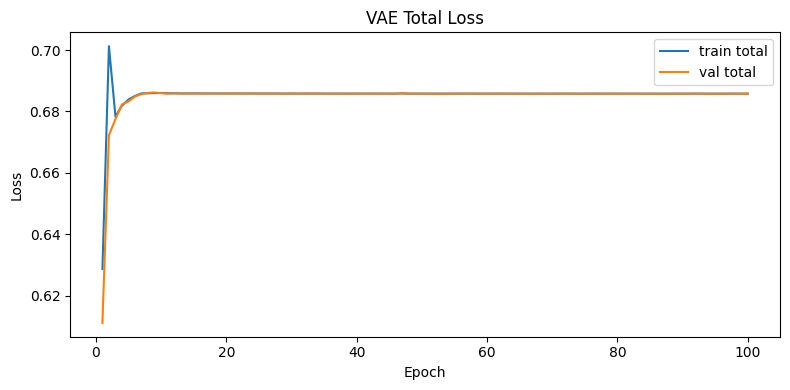

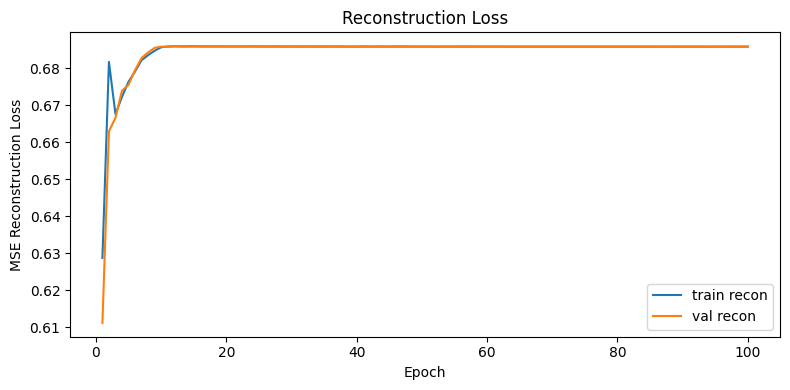

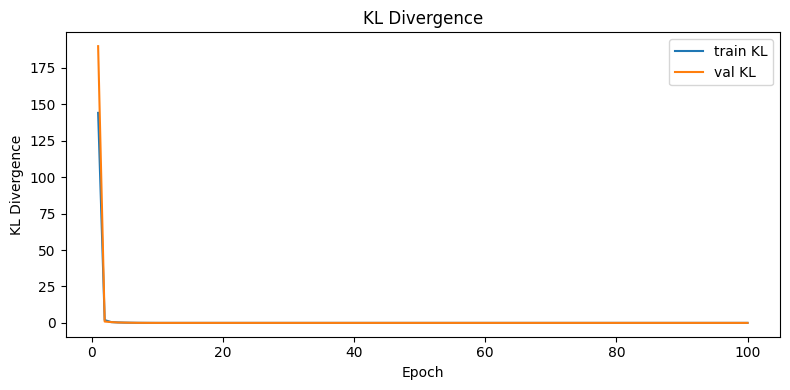

In [27]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, history["train_total"], label="train total")
plt.plot(epochs, history["val_total"],   label="val total")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Total Loss")
plt.legend(); plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, history["train_recon"], label="train recon")
plt.plot(epochs, history["val_recon"],   label="val recon")
plt.xlabel("Epoch")
plt.ylabel("MSE Reconstruction Loss")
plt.title("Reconstruction Loss")
plt.legend(); plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, history["train_kl"], label="train KL")
plt.plot(epochs, history["val_kl"],   label="val KL")
plt.xlabel("Epoch")
plt.ylabel("KL Divergence")
plt.title("KL Divergence")
plt.legend(); plt.tight_layout()
plt.show()


### **Visualizing Reconstructions**

We now evaluate how well our **VAE** reconstructs faces and compare those outputs to a **plain Autoencoder (AE)**.  
This helps us see the practical effect of a **probabilistic latent space**: VAE reconstructions often look **slightly softer** than AE outputs, reflecting the trade-off between **sharpness** and **latent smoothness**.

> The VAE encourages a continuous, sampleable latent manifold. In practice, this can blur fine details a bit, but it **improves generative consistency**.

**VAE: Original vs. Reconstructed Pairs**

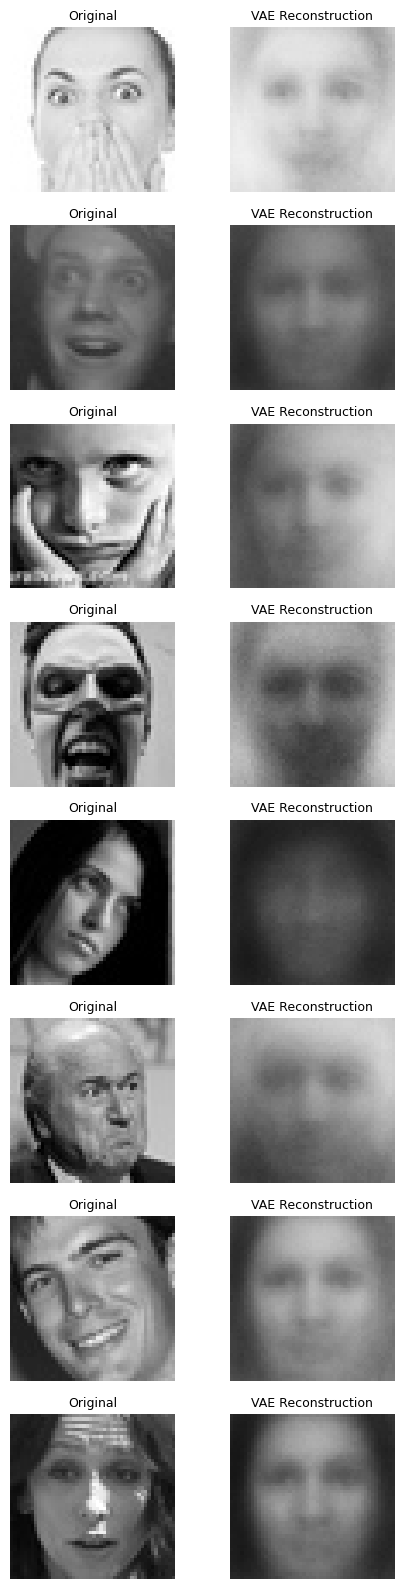

In [28]:
try:
    X_val_t
except NameError:
    import numpy as np
    from sklearn.model_selection import train_test_split
    data = np.load("/content/drive/MyDrive/fer2013_full.npz")
    X, y = data["X"], data["y"]
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=y
    )
    X_val_t = torch.tensor(X_val, dtype=torch.float32).view(X_val.shape[0], -1)

device = next(model.parameters()).device
model.eval()

# Select a small batch
idx = torch.randperm(X_val_t.size(0))[:8]
xb = X_val_t[idx].to(device)                      # (N, 2304)
with torch.no_grad():
    x_recon, mu, logvar = model(xb)               # (N, 2304)
xb_img     = xb.view(-1, 48, 48).cpu().numpy()
xrecon_img = x_recon.view(-1, 48, 48).cpu().numpy()

# Plot original vs reconstructed (VAE)
n = xb_img.shape[0]
rows = n
fig, axes = plt.subplots(rows, 2, figsize=(5, 2*rows))
for i in range(rows):
    axes[i, 0].imshow(xb_img[i], cmap="gray", vmin=0.0, vmax=1.0)
    axes[i, 0].set_title("Original", fontsize=9); axes[i, 0].axis("off")

    axes[i, 1].imshow(xrecon_img[i], cmap="gray", vmin=0.0, vmax=1.0)
    axes[i, 1].set_title("VAE Reconstruction", fontsize=9); axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


In [30]:
INPUT_DIM = 48 * 48         # 2304
LATENT_DIM = 128

class FC_Autoencoder(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        # Encoder: 2304 -> 512 -> 128
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, latent_dim),
            nn.ReLU(inplace=True),
        )
        # Decoder: 128 -> 512 -> 2304
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, input_dim),
            nn.Sigmoid()  # constrain output to [0, 1]
        )

    def forward(self, x):
        """
        x: (N, 1, 48, 48) or (N, 48, 48)
        returns: reconstruction with same shape as input
        """
        # Ensure shape is (N, 48, 48)
        if x.dim() == 4:        # (N, 1, 48, 48)
            x = x.squeeze(1)
        # Flatten to (N, 2304)
        n = x.size(0)
        x_flat = x.view(n, -1)
        # Encode -> Decode
        z = self.encoder(x_flat)
        x_hat_flat = self.decoder(z)
        # Reshape back to (N, 48, 48)
        x_hat = x_hat_flat.view(n, 48, 48)
        # Add channel dim back to be consistent with PyTorch image conventions
        x_hat = x_hat.unsqueeze(1)  # (N, 1, 48, 48)
        return x_hat

ae_model = FC_Autoencoder().to(device)
ae_model.load_state_dict(torch.load("/content/drive/MyDrive/ae_model.pth", map_location=device))
ae_model.eval()


FC_Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=2304, out_features=512, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=512, out_features=2304, bias=True)
    (3): Sigmoid()
  )
)

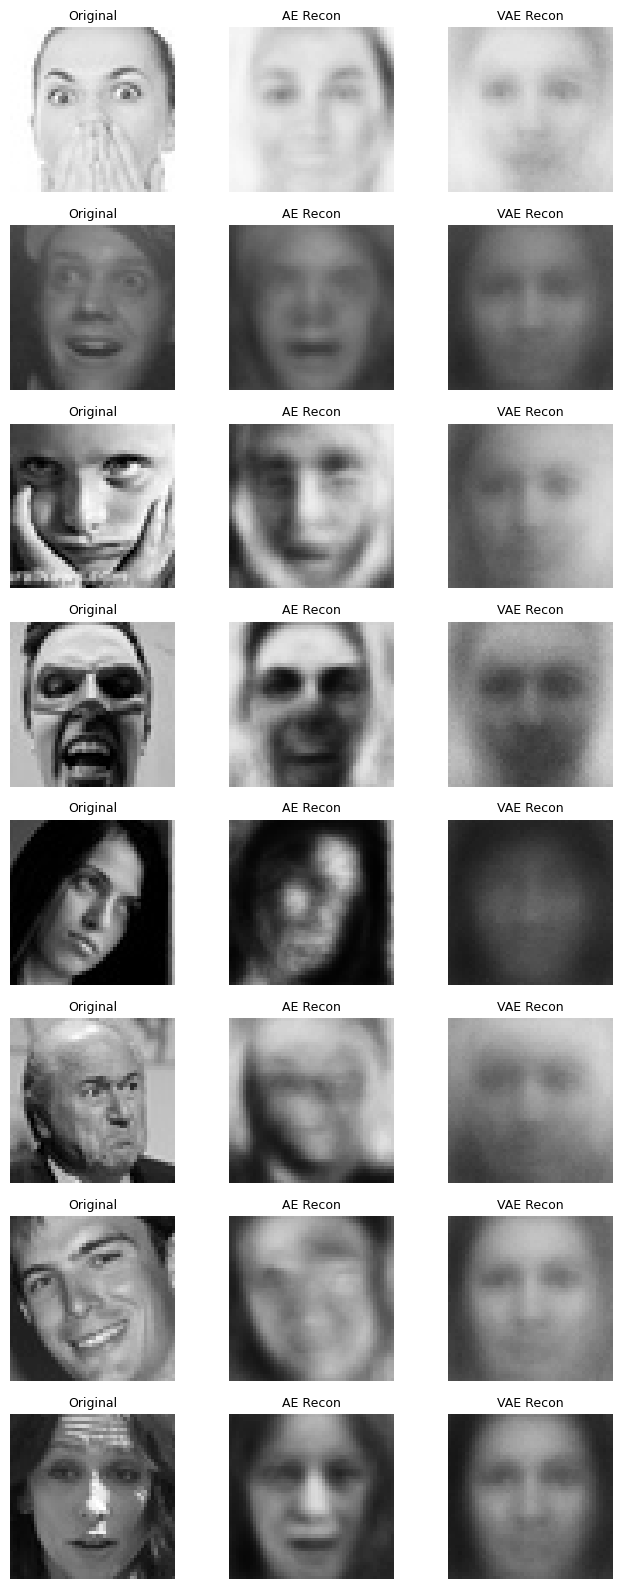

In [31]:
try:
    _ = ae_model
    ae_model = ae_model.to(device).eval()

    with torch.no_grad():
        ae_recon = ae_model(xb)  # (N, 2304)

    ae_img = ae_recon.view(-1, 48, 48).detach().cpu().numpy()

    # Grid: Original | AE Recon | VAE Recon
    n = xb_img.shape[0]
    fig, axes = plt.subplots(n, 3, figsize=(7, 2*n))
    for i in range(n):
        axes[i, 0].imshow(xb_img[i], cmap="gray", vmin=0.0, vmax=1.0)
        axes[i, 0].set_title("Original", fontsize=9); axes[i, 0].axis("off")

        axes[i, 1].imshow(ae_img[i], cmap="gray", vmin=0.0, vmax=1.0)
        axes[i, 1].set_title("AE Recon", fontsize=9); axes[i, 1].axis("off")

        axes[i, 2].imshow(xrecon_img[i], cmap="gray", vmin=0.0, vmax=1.0)
        axes[i, 2].set_title("VAE Recon", fontsize=9); axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

except NameError:
    print("AE model `ae_model` not found. Skipping AE vs VAE comparison. "
          "Provide a trained AE (flattened 2304 → 2304 with Sigmoid) as `ae_model` to enable this plot.")


**Interpretation**

- VAE Reconstructions:

Often softer than AE outputs. This is expected because the VAE’s latent space is regularized toward a simple prior, trading a bit of pixel-level sharpness for smooth, continuous representations.

- AE vs. VAE:

    - AE focuses strictly on minimizing reconstruction error → sometimes sharper details.

    - VAE balances reconstruction with KL regularization, shaping a sampleable latent space that supports generation and smooth interpolation.

### **Generating Synthetic Faces**

We now demonstrate the **generative power** of our VAE.  
Unlike a plain autoencoder that only reconstructs given inputs, a VAE learns a **probabilistic latent space**. By **sampling** latent vectors
$$
z \sim \mathcal{N}(0, I),
$$
and decoding them, we can generate **new faces** that resemble the training distribution without copying any single image.

In [33]:
device = next(model.parameters()).device
model.eval()

NUM = 16
LATENT_DIM = model.fc_mu.out_features  # infer latent size from the encoder head

# Sample z ~ N(0, I)
with torch.no_grad():
    z = torch.randn(NUM, LATENT_DIM, device=device)
    x_gen = model.decode(z)                     # (NUM, 2304) if our VAE outputs flat vectors
    x_gen = x_gen.view(NUM, 48, 48).cpu().numpy()

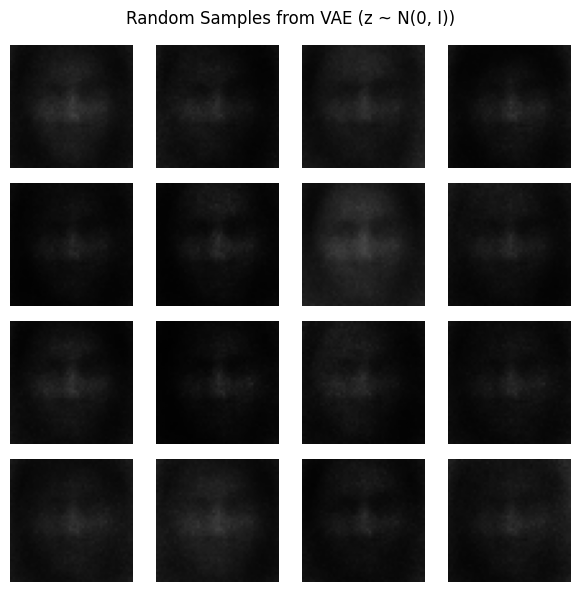

In [34]:
n = int(np.sqrt(NUM))
fig, axes = plt.subplots(n, n, figsize=(6, 6))
k = 0
for i in range(n):
    for j in range(n):
        axes[i, j].imshow(x_gen[k], cmap="gray", vmin=0.0, vmax=1.0)
        axes[i, j].axis("off")
        k += 1
plt.suptitle("Random Samples from VAE (z ~ N(0, I))", fontsize=12)
plt.tight_layout()
plt.show()

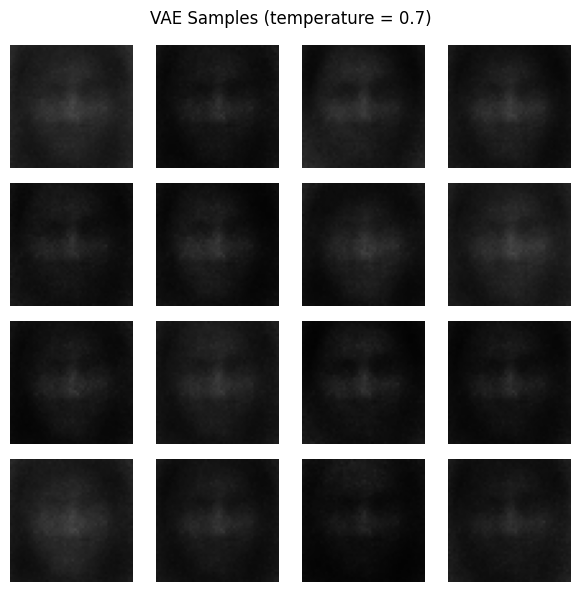

In [35]:
temperature = 0.7
with torch.no_grad():
    z = torch.randn(NUM, LATENT_DIM, device=device) * temperature
    x_gen_t = model.decode(z).view(NUM, 48, 48).cpu().numpy()

fig, axes = plt.subplots(n, n, figsize=(6, 6))
k = 0
for i in range(n):
    for j in range(n):
        axes[i, j].imshow(x_gen_t[k], cmap="gray", vmin=0.0, vmax=1.0)
        axes[i, j].axis("off")
        k += 1
plt.suptitle(f"VAE Samples (temperature = {temperature})", fontsize=12)
plt.tight_layout()
plt.show()

**Reflection**

- Plausible facial structure: eyes, nose bridge, mouth contour, and overall head shape should appear coherent.
- Diversity vs. sharpness trade-off: higher temperature yields more variety but may blur details; lower temperature yields safer, more typical faces.
- No exact duplicates: outputs should be new faces drawn from the model’s learned distribution, not copies of training images.

### **Exploring the Latent Space**

A key advantage of our VAE is the **structured latent space** it learns.  
By visualizing this space, we can see whether faces with similar expressions or geometry lie close together.  
We will project the encoder’s **mean vectors (μ)** to 2D using **PCA** or **t-SNE** and color points by emotion labels.

In [37]:
try:
    X_val, y_val
except NameError:
    data = np.load("/content/drive/MyDrive/fer2013_full.npz")
    X, y = data["X"], data["y"]
    from sklearn.model_selection import train_test_split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=y
    )


X_val_t = torch.tensor(X_val, dtype=torch.float32).view(X_val.shape[0], -1)
val_ds = TensorDataset(X_val_t, torch.tensor(y_val))
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

device = next(model.parameters()).device
model.eval()

# -- μ (latent means)
mus = []
labs = []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        mu, logvar = model.encode(xb)
        mus.append(mu.cpu().numpy())
        labs.append(yb.numpy())

Z_mu = np.concatenate(mus, axis=0)         # shape (N, latent_dim)
y_val_np = np.concatenate(labs, axis=0)

print("Encoded μ shape:", Z_mu.shape, "labels:", y_val_np.shape)

Encoded μ shape: (7178, 32) labels: (7178,)


**2D Projection (PCA or t-SNE)**

- PCA is fast and gives a linear projection.
- t-SNE can reveal non-linear structure but is slower; we often apply PCA to 30 dims first, then t-SNE.

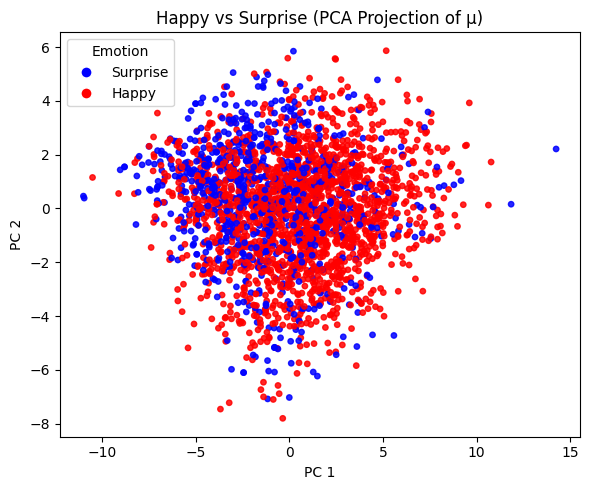

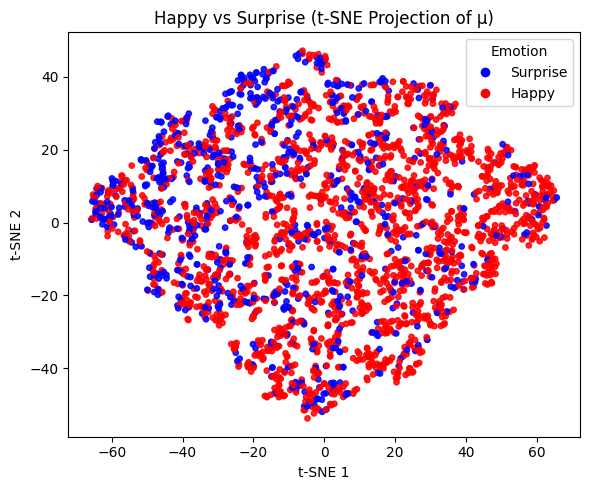

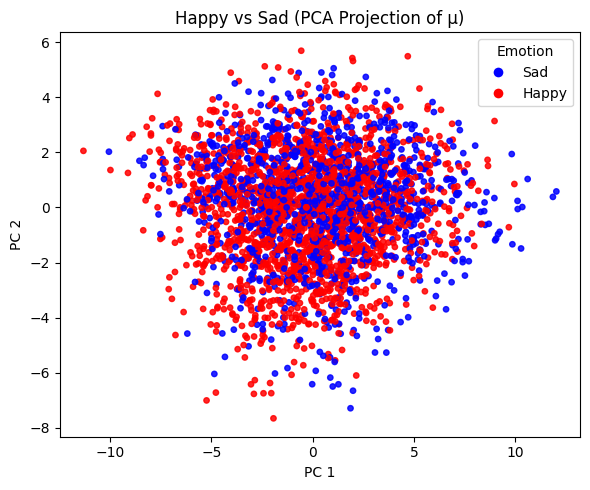

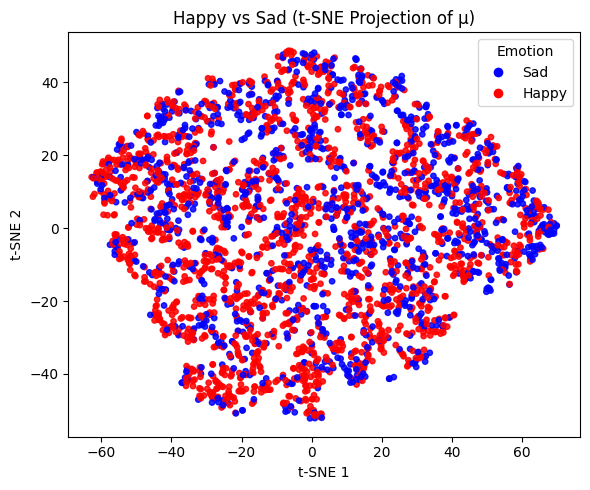

In [38]:

emotions = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

pairs = [
    (3, 5, "Happy vs Surprise"),
    (3, 4, "Happy vs Sad"),
]

for a, b, title in pairs:
    # Filter only the two chosen emotions
    mask = np.isin(y_val_np, [a, b])
    Z_pair = Z_mu[mask]
    y_pair = y_val_np[mask]

    # Re-label to binary (0,1) for consistent color
    y_binary = (y_pair == a).astype(int)  # 1 = Happy, 0 = other

    # Standardize is optional (useful for t-SNE stability)
    # --- PCA (2D) ---
    Z_pca = PCA(n_components=2, random_state=42).fit_transform(Z_pair)

    plt.figure(figsize=(6,5))
    plt.scatter(Z_pca[:,0], Z_pca[:,1], c=y_binary, cmap="bwr", s=15, alpha=0.85)

    # Custom legend
    handles = [
        plt.Line2D([], [], marker="o", color="w", markerfacecolor="blue", markersize=8,
                   label=emotions[b]),
        plt.Line2D([], [], marker="o", color="w", markerfacecolor="red", markersize=8,
                   label=emotions[a]),
    ]
    plt.legend(handles=handles, title="Emotion", loc="best")
    plt.title(f"{title} (PCA Projection of μ)")
    plt.xlabel("PC 1"); plt.ylabel("PC 2")
    plt.tight_layout()
    plt.show()

    # --- t-SNE (optional) ---
    # First reduce to (at most) 30D for speed
    Z_30 = PCA(n_components=min(30, Z_pair.shape[1]), random_state=42).fit_transform(Z_pair)
    Z_tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto",
                  init="pca", random_state=42).fit_transform(Z_30)

    plt.figure(figsize=(6,5))
    plt.scatter(Z_tsne[:,0], Z_tsne[:,1], c=y_binary, cmap="bwr", s=15, alpha=0.85)

    # Same legend
    plt.legend(handles=handles, title="Emotion", loc="best")
    plt.title(f"{title} (t-SNE Projection of μ)")
    plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()

**Reflection**

- If points with the same emotion tend to cluster, our encoder is capturing shared expression cues and facial geometry.
- PCA may show broad separation (e.g., strong smiles vs. neutral), while t-SNE can reveal finer groupings.
- Overlap is normal: emotions share features (eyes, head pose, lighting). What matters is that the space is smooth and semantically organized.